In [ ]:
import os
import time

print("1. Installing Java 11 and dependencies...")
!apt-get update -qq > /dev/null
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pathway kafka-python fastapi uvicorn scikit-learn pandas matplotlib seaborn nest-asyncio joblib

# Set Kaggle credentials
os.environ['KAGGLE_USERNAME'] = #"kaggle username"
os.environ['KAGGLE_KEY'] = #"kaggle key"

print("2. Downloading and unzipping Kaggle Dataset...")
!pip install -q kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q -o creditcardfraud.zip
print("Dataset downloaded and unzipped successfully!")

1. Installing Java 11 and dependencies...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 606.6/606.6 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.6/777.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 

In [ ]:
import os
import time

print("1. Installing Java 11 and dependencies...")
!apt-get update -qq > /dev/null
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pathway kafka-python joblib scikit-learn matplotlib pandas xgboost fastapi uvicorn nest-asyncio

# FORCING THE JAVA PATH
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# Forcing memory limits for Colab
os.environ["KAFKA_HEAP_OPTS"] = "-Xmx256M -Xms256M"

print("2. Downloading Kafka from the Permanent Archive...")
# THESE ARE NOW STRICTLY ON SEPARATE LINES
!rm -rf kafka_2.13-3.7.0*
!wget https://archive.apache.org/dist/kafka/3.7.0/kafka_2.13-3.7.0.tgz
!tar -xzf kafka_2.13-3.7.0.tgz

print("3. Starting Zookeeper...")
!nohup ./kafka_2.13-3.7.0/bin/zookeeper-server-start.sh ./kafka_2.13-3.7.0/config/zookeeper.properties > zookeeper.log 2>&1 &
time.sleep(10)

print("4. Starting Kafka Broker...")
!nohup ./kafka_2.13-3.7.0/bin/kafka-server-start.sh ./kafka_2.13-3.7.0/config/server.properties > kafka.log 2>&1 &
time.sleep(15)

print("\n--- SYSTEM DIAGNOSTIC ---")
!jps

print("\n5. Creating Kafka Topics...")
!./kafka_2.13-3.7.0/bin/kafka-topics.sh --create --bootstrap-server localhost:9092 --replication-factor 1 --partitions 1 --topic transactions
!./kafka_2.13-3.7.0/bin/kafka-topics.sh --create --bootstrap-server localhost:9092 --replication-factor 1 --partitions 1 --topic fraud_alerts

1. Installing Java 11 and dependencies...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
2. Downloading Kafka from the Permanent Archive...
--2026-06-20 16:44:11--  https://archive.apache.org/dist/kafka/3.7.0/kafka_2.13-3.7.0.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 119028138 (114M) [application/x-gzip]
Saving to: ‘kafka_2.13-3.7.0.tgz’

kafka_2.13-3.7.0.tg 100%[===================>] 113.51M  16.5MB/s    in 8.1s    

2026-06-20 16:44:20 (14.0 MB/s) - ‘kafka_2.13-3.7.0.tgz’ saved [119028138/119028138]

3. Starting Zookeeper...
4. Starting Kafka Broker...

--- SYSTEM DIAGNOSTIC ---
12289 QuorumPeerMain
13267 Jps
12745 Kafka

5. Creating Kafka Topics...
Crea

In [ ]:
import os
import pandas as pd
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split

# 1. Ensure XGBoost is installed
!pip install -q xgboost

os.environ['KAGGLE_USERNAME'] = #"kaggle username"
os.environ['KAGGLE_KEY'] = #"kaggle key"

# 3. Download and unzip the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q -o creditcardfraud.zip
print("Dataset downloaded and unzipped successfully!")

# 4. Prepare data for XGBoost
print("Preparing data and training the XGBoost model...")
df = pd.read_csv('creditcard.csv')

# Separate features (X) from the target label (y)
# We drop 'Time' because it's a running counter, which isn't useful for this real-time model
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

# Use a 20% sample for faster Colab execution, while maintaining the ratio of fraud/normal
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

# Calculate weight to handle the extreme imbalance (Normal >> Fraud)
# Formula: count(negative examples) / count(positive examples)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# 5. Train the XGBoost Classifier
model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_weight,  # Forces model to care more about the rare fraud cases
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
model.fit(X_train, y_train)

# 6. Save the trained XGBoost model to disk
joblib.dump(model, 'xgboost_fraud_model.joblib')
print("XGBoost Model trained and saved as 'xgboost_fraud_model.joblib'!")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and unzipped successfully!
Preparing data and training the XGBoost model...
XGBoost Model trained and saved as 'xgboost_fraud_model.joblib'!


Evaluating the XGBoost Model on Test Data...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC SCORE: 0.9691


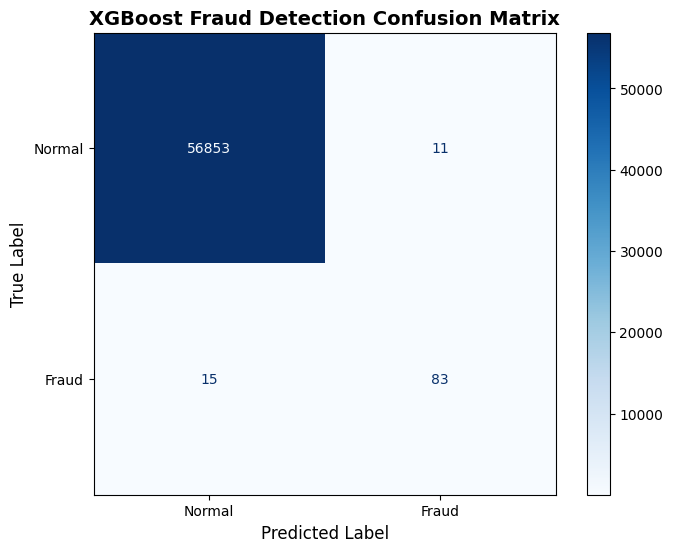

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Evaluating the XGBoost Model on Test Data...")

# 1. Generate predictions and probabilities from the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Print Classification Report (Precision, Recall, F1-Score)
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fraud (1)']))

# 3. Calculate and Print ROC-AUC Score
# ROC-AUC measures the model's ability to distinguish between classes.
# 1.0 is perfect, 0.5 is guessing randomly.
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("="*50)
print(f"ROC-AUC SCORE: {roc_auc:.4f}")
print("="*50)

# 4. Plot a visually appealing Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

# Styling the plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('XGBoost Fraud Detection Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Display the graph in Colab
plt.show()


Applying Custom Strictness Threshold: 0.5
STRICT CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



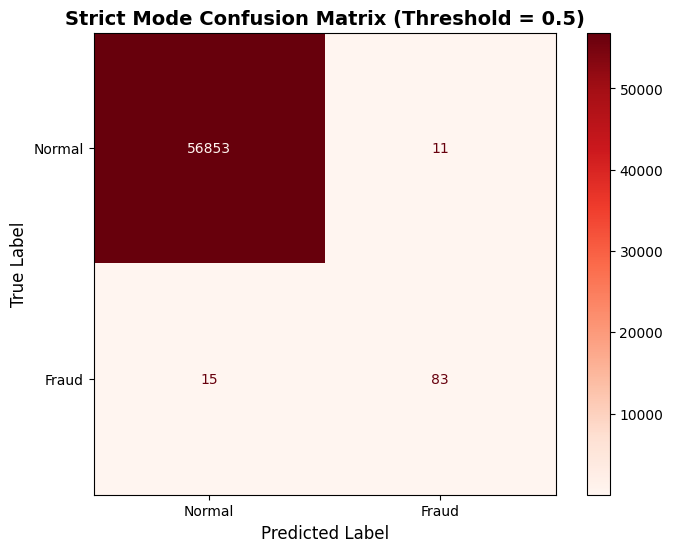

In [ ]:
import numpy as np

# Let's set a strict threshold.
# Instead of > 0.50, we will flag fraud if the model is even 10% suspicious.
STRICT_THRESHOLD = 0.50

print(f"Applying Custom Strictness Threshold: {STRICT_THRESHOLD}")
print("="*50)

# 1. Get the raw probability scores instead of the final predictions
probabilities = model.predict_proba(X_test)[:, 1]

# 2. Apply our custom threshold
y_pred_strict = (probabilities >= STRICT_THRESHOLD).astype(int)

# 3. Print the new results
print("STRICT CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_strict, target_names=['Normal (0)', 'Fraud (1)']))

# 4. Show the new Confusion Matrix
cm_strict = confusion_matrix(y_test, y_pred_strict)
disp_strict = ConfusionMatrixDisplay(
    confusion_matrix=cm_strict,
    display_labels=['Normal', 'Fraud']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp_strict.plot(cmap='Reds', values_format='d', ax=ax) # Using red to signify the strict alert mode
plt.title(f'Strict Mode Confusion Matrix (Threshold = {STRICT_THRESHOLD})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from kafka import KafkaProducer
import json
import threading
from typing import Dict, Any

nest_asyncio.apply()
app = FastAPI()

producer = KafkaProducer(
    bootstrap_servers=['localhost:9092'],
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

@app.post("/transaction")
def ingest_transaction(tx: Dict[str, Any]):
    producer.send("transactions", tx)
    return {"status": "Queued in Kafka"}

def run_api():
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="warning")

threading.Thread(target=run_api, daemon=True).start()
print("FastAPI running on http://127.0.0.1:8000")

FastAPI running on http://127.0.0.1:8000


In [ ]:
import requests
import pandas as pd

df = pd.read_csv('creditcard.csv')
fraud_sample = df[df['Class'] == 1].iloc[0].drop(['Class', 'Time']).to_dict()

response = requests.post("http://127.0.0.1:8000/transaction", json=fraud_sample)
print("Fired into Kafka:", response.json())

Fired into Kafka: {'status': 'Queued in Kafka'}


In [ ]:
import pathway as pw
import joblib
import json
import pandas as pd
import time

# Load Model
model = joblib.load('xgboost_fraud_model.joblib')
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']

@pw.udf
# FIXED: Pathway reads 'raw' format as bytes, so we need to decode it first
def predict_fraud(raw_data: bytes) -> int:
    try:
        json_str = raw_data.decode('utf-8')
        data = json.loads(json_str)
        df_live = pd.DataFrame([data])
        X_live = df_live[feature_cols]
        return int(model.predict(X_live)[0])
    except Exception as e:
        return -1

# FIXED: A dynamic group ID ensures Kafka gives us ALL messages from the beginning, every time.
unique_group_id = f"pathway-group-{int(time.time())}"

kafka_settings = {
    "bootstrap.servers": "localhost:9092",
    "group.id": unique_group_id,
    "auto.offset.reset": "earliest"
}

transactions_stream = pw.io.kafka.read(kafka_settings, topic="transactions", format="raw")

analyzed_stream = transactions_stream.with_columns(
    is_fraud=predict_fraud(pw.this.data)
)

frauds_only = analyzed_stream.filter(pw.this.is_fraud == 1)

pw.io.csv.write(frauds_only, "detected_frauds.csv")
pw.io.kafka.write(frauds_only, kafka_settings, topic_name="fraud_alerts", format="json")

print("Pathway Engine is running...")
pw.run()

Output()

Pathway Engine is running...


KeyboardInterrupt: 